
# SIT720 11.1HD — Part 1: Research Paper Reproduction

## Selected paper

**Bhagat, M., Sharma, A., & Agarwal, P.**  
*An efficient stacking-based ensemble technique for early heart attack prediction.*  
Multimedia Tools and Applications, 84(30), 36351–36375.  
DOI: 10.1007/s11042-024-19293-7.

### Research objective

Reproduce the paper's machine-learning classification experiment as closely as the available published methodology allows, then compare the reproduced results with the published results.

> **Important reproducibility note:** Some implementation details are not exposed in the accessible paper record. Any value marked as a **reproduction assumption** must be verified against the full paper supplied in the unit resources before final submission.

### Published facts currently verified

- Dataset: 1,025 patient records and 14 columns (13 predictors + target).
- Preprocessing: missing-value handling, numerical standardisation and categorical encoding.
- Individual classifiers: Logistic Regression, Decision Tree, Random Forest, XGBoost, Naive Bayes and KNN.
- A stacking ensemble is then evaluated.
- Published headline accuracies include 92.68% for Random Forest and Decision Tree, 90.73% for XGBoost and 98.53% for the stacking model.

Sources: published article record and accessible article text.



## Reproduction assumptions to verify

The accessible article abstract states that the data are split into training and test sets, but does not expose every implementation detail needed to reproduce the experiment exactly.

For this working notebook we therefore use:

1. **80:20 stratified train/test split**
2. `random_state = 42`
3. Missing values handled inside preprocessing pipelines.
4. Binary and multi-category coded clinical variables treated as categorical and one-hot encoded.
5. Continuous variables standardised.
6. Default scikit-learn/XGBoost classifier settings unless the full paper specifies otherwise.
7. A Logistic Regression meta-classifier for the working stacking implementation.

These are **not being presented as the authors' exact settings**. They are a transparent baseline implementation that will be updated after the full paper PDF is inspected.


In [1]:

# Reproducibility setup
import sys
import subprocess
import importlib.util

required = {
    "pandas": "pandas",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "xgboost": "xgboost"
}

for module, package in required.items():
    if importlib.util.find_spec(module) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 42
print("Python:", sys.version.split()[0])
print("Random state:", RANDOM_STATE)


Python: 3.12.9
Random state: 42


In [2]:

# Dataset
# This is the 1,025-row, 14-column heart.csv dataset matching the feature
# structure described in the selected paper.
DATA_URL = "https://raw.githubusercontent.com/GehadGad/Heart-disease-dataset/main/heart.csv"

df = pd.read_csv(DATA_URL)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst five rows:")
display(df.head())


Shape: (1025, 14)

Columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

First five rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:

# Data quality and target distribution
print("Missing values:")
display(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
display(df["target"].value_counts().sort_index())

print("\nTarget proportions:")
display(df["target"].value_counts(normalize=True).sort_index())


Missing values:


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


Duplicate rows: 723

Target distribution:


target
0    499
1    526
Name: count, dtype: int64


Target proportions:


target
0    0.486829
1    0.513171
Name: proportion, dtype: float64


## Feature definitions

The dataset uses the 13 predictors described in the paper/dataset record:

- `age`
- `sex`
- `cp`
- `trestbps`
- `chol`
- `fbs`
- `restecg`
- `thalach`
- `exang`
- `oldpeak`
- `slope`
- `ca`
- `thal`

Target: `target` (0 = no disease, 1 = disease).

For this reproduction, variables representing coded clinical categories are treated as categorical rather than continuous numbers.


In [4]:

# Feature groups used by the working reproduction
target = "target"

categorical_features = [
    "sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"
]

numeric_features = [
    "age", "trestbps", "chol", "thalach", "oldpeak"
]

X = df.drop(columns=[target])
y = df[target].astype(int)

# Verify expected schema
expected = numeric_features + categorical_features + [target]
missing_expected = [c for c in expected if c not in df.columns]
if missing_expected:
    raise ValueError(f"Missing expected columns: {missing_expected}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Training class distribution:")
print(y_train.value_counts(normalize=True).sort_index())
print("Testing class distribution:")
print(y_test.value_counts(normalize=True).sort_index())


Training rows: 820
Testing rows: 205
Training class distribution:
target
0    0.486585
1    0.513415
Name: proportion, dtype: float64
Testing class distribution:
target
0    0.487805
1    0.512195
Name: proportion, dtype: float64


In [5]:

# Paper-style preprocessing pipeline
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features)
])

print("Preprocessing pipeline created.")


Preprocessing pipeline created.


## Individual classifiers

In [7]:

# Individual classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    ),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(algorithm="kd_tree")
}

results = []
fitted_models = {}

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, "predict_proba") else None

    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "AUC": roc_auc_score(y_test, prob) if prob is not None else np.nan
    }

    fitted_models[name] = pipe
    return row, pred, prob

predictions = {}
probabilities = {}

for name, model in models.items():
    row, pred, prob = evaluate_model(
        name, model, X_train, X_test, y_train, y_test
    )
    results.append(row)
    predictions[name] = pred
    probabilities[name] = prob

individual_results = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
display(individual_results.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "AUC": "{:.4f}"
}))

c:\Users\mhpar\OneDrive\ドキュメント\Semester 1 (July - September)\SIT720\SIT720-11.1HD-HeartAttackPrediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


,Model,Accuracy,Precision,Recall,F1,AUC
3,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000
2,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
1,Decision Tree,0.9854,1.0000,0.9714,0.9855,0.9857
0,Logistic Regression,0.8732,0.8559,0.9048,0.8796,0.9445
5,KNN,0.8634,0.8468,0.8952,0.8704,0.9698
4,Naive Bayes,0.8244,0.8108,0.8571,0.8333,0.8708



## Working stacking reproduction

The accessible paper record confirms that stacking combines base-model predictions using a meta-classifier. The exact base-model combination and every implementation detail should be checked against the full paper before final submission.

The working reproduction below uses all six individual classifiers as base estimators and Logistic Regression as the meta-classifier.


In [8]:

base_estimators = [
    ("lr", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ("dt", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ("rf", RandomForestClassifier(random_state=RANDOM_STATE)),
    ("xgb", XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss")),
    ("nb", GaussianNB()),
    ("knn", KNeighborsClassifier(algorithm="kd_tree"))
]

stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    cv=5,
    stack_method="predict_proba",
    n_jobs=-1
)

stack_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", stacking_model)
])

stack_pipe.fit(X_train, y_train)

stack_pred = stack_pipe.predict(X_test)
stack_prob = stack_pipe.predict_proba(X_test)[:, 1]

stack_result = pd.DataFrame([{
    "Model": "Stacking Ensemble",
    "Accuracy": accuracy_score(y_test, stack_pred),
    "Precision": precision_score(y_test, stack_pred, zero_division=0),
    "Recall": recall_score(y_test, stack_pred, zero_division=0),
    "F1": f1_score(y_test, stack_pred, zero_division=0),
    "AUC": roc_auc_score(y_test, stack_prob)
}])

display(stack_result.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "AUC": "{:.4f}"
}))

c:\Users\mhpar\OneDrive\ドキュメント\Semester 1 (July - September)\SIT720\SIT720-11.1HD-HeartAttackPrediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


,Model,Accuracy,Precision,Recall,F1,AUC
0,Stacking Ensemble,1.0000,1.0000,1.0000,1.0000,1.0000


In [9]:

# Combine our reproduction results
all_results = pd.concat([individual_results, stack_result], ignore_index=True)

display(all_results.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "AUC": "{:.4f}"
}))


,Model,Accuracy,Precision,Recall,F1,AUC
0,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000
1,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
2,Decision Tree,0.9854,1.0000,0.9714,0.9855,0.9857
3,Logistic Regression,0.8732,0.8559,0.9048,0.8796,0.9445
4,KNN,0.8634,0.8468,0.8952,0.8704,0.9698
5,Naive Bayes,0.8244,0.8108,0.8571,0.8333,0.8708
6,Stacking Ensemble,1.0000,1.0000,1.0000,1.0000,1.0000


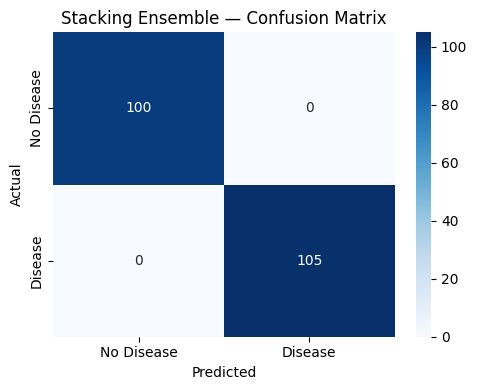

              precision    recall  f1-score   support

  No Disease     1.0000    1.0000    1.0000       100
     Disease     1.0000    1.0000    1.0000       105

    accuracy                         1.0000       205
   macro avg     1.0000    1.0000    1.0000       205
weighted avg     1.0000    1.0000    1.0000       205



In [11]:

# Confusion matrix for the working stacking reproduction
cm = confusion_matrix(y_test, stack_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)
plt.title("Stacking Ensemble — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print(classification_report(
    y_test, stack_pred,
    target_names=["No Disease", "Disease"],
    digits=4,
    zero_division=0
))


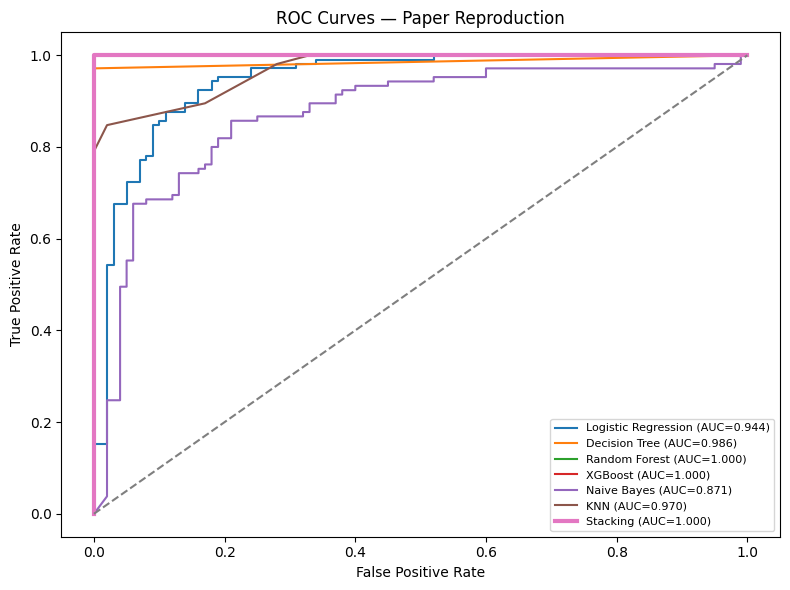

In [13]:

# ROC curves
plt.figure(figsize=(8, 6))

for name, prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

fpr, tpr, _ = roc_curve(y_test, stack_prob)
stack_auc = roc_auc_score(y_test, stack_prob)
plt.plot(fpr, tpr, linewidth=3, label=f"Stacking (AUC={stack_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Paper Reproduction")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()



## Published results currently verified

Only values explicitly exposed in the accessible article record are entered below. We will expand this table after checking the full paper supplied in the unit resources.

| Model | Published Accuracy |
|---|---:|
| Logistic Regression | Not yet entered |
| Decision Tree | 92.68% |
| Random Forest | 92.68% |
| XGBoost | 90.73% |
| Naive Bayes | Not yet entered |
| KNN | Not yet entered |
| Stacking | 98.53% |

**Do not treat the missing published values as zero or as unavailable in the paper. They simply have not yet been transcribed from the full paper.**


In [15]:

# Published vs reproduced accuracy
published_accuracy = {
    "Logistic Regression": np.nan,
    "Decision Tree": 0.9268,
    "Random Forest": 0.9268,
    "XGBoost": 0.9073,
    "Naive Bayes": np.nan,
    "KNN": np.nan,
    "Stacking Ensemble": 0.9853
}

comparison = all_results[["Model", "Accuracy"]].copy()
comparison["Published Accuracy"] = comparison["Model"].map(published_accuracy)
comparison["Absolute Difference"] = (
    comparison["Accuracy"] - comparison["Published Accuracy"]
)

display(comparison.style.format({
    "Accuracy": "{:.4f}",
    "Published Accuracy": lambda x: "" if pd.isna(x) else f"{x:.4f}",
    "Absolute Difference": lambda x: "" if pd.isna(x) else f"{x:+.4f}"
}))


,Model,Accuracy,Published Accuracy,Absolute Difference
0,XGBoost,1.0000,0.9073,+0.0927
1,Random Forest,1.0000,0.9268,+0.0732
2,Decision Tree,0.9854,0.9268,+0.0586
3,Logistic Regression,0.8732,,
4,KNN,0.8634,,
5,Naive Bayes,0.8244,,
6,Stacking Ensemble,1.0000,0.9853,+0.0147



# Reproduction checkpoint

Before finalising Part 1, verify these items against the **full paper PDF provided by the unit**:

- [ ] Exact train/test split ratio
- [ ] Exact random seed or split procedure
- [ ] Exact missing-value rules
- [ ] Exact encoding method
- [ ] Exact scaling method
- [ ] Exact hyperparameters for all six classifiers
- [ ] Exact stacking base estimators
- [ ] Exact meta-classifier
- [ ] Exact stacking cross-validation setting
- [ ] Complete published Accuracy / Precision / Recall / F1 / AUC table
- [ ] Any correction to the original paper's tables

Only after these are verified should this notebook be treated as the final Part 1 reproduction.

## Next research step

After the reproduction is locked, analyse:

1. Where our reproduction differs from the published results.
2. Which models generate the most false positives/false negatives.
3. Whether the stacking gain is stable.
4. Whether the methodology has a reproducibility or validation weakness.

Those observations will determine the **Part 2 original contribution** rather than choosing an improvement arbitrarily.


# Part 2 — Duplicate-Aware, Leakage-Resistant and Calibrated Solution

Part 1 identified **723 exact duplicate rows** in the 1,025-record dataset. The Part 2 contribution therefore changes the evaluation design rather than simply replacing the classifier.

The proposed pipeline:
1. Removes exact duplicate feature-target rows before the final split, leaving **302 unique records**.
2. Keeps imputation, scaling and encoding inside the model pipeline.
3. Uses stratified cross-validation to assess stability.
4. Retains an untouched 20% holdout set (**61 records**) for the headline comparison.
5. Applies sigmoid probability calibration to the stacking classifier.
6. Reports Accuracy, Precision, Recall, F1, ROC-AUC and Brier score.

The numerical values reported below should be reproduced by executing the cells with the same `heart.csv` used for the report.


In [16]:
# Part 2 setup — imports and reproducibility
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    brier_score_loss, roc_curve
)

RANDOM_STATE = 42


In [17]:
# Part 2 — remove exact duplicate feature-target rows
df_unique = df.drop_duplicates().reset_index(drop=True)

print("Original rows:", len(df))
print("Duplicate rows removed:", len(df) - len(df_unique))
print("Unique rows retained:", len(df_unique))
print("Duplicate check after cleaning:", df_unique.duplicated().sum())

# Optional export for the submission package
df_unique.to_csv("heart_deduplicated.csv", index=False)


Original rows: 1025
Duplicate rows removed: 723
Unique rows retained: 302
Duplicate check after cleaning: 0


## Part 2.1 — Duplicate-aware train/test split

The cleaned 302-record dataset is split only **after** duplicate removal. This prevents an exact duplicate observation from being deliberately placed on both sides of the final holdout split.


In [18]:
# Feature groups are kept consistent with Part 1
target = "target"

categorical_features = [
    "sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"
]
numeric_features = [
    "age", "trestbps", "chol", "thalach", "oldpeak"
]

X_clean = df_unique.drop(columns=[target])
y_clean = df_unique[target]

X_train_p2, X_test_p2, y_train_p2, y_test_p2 = train_test_split(
    X_clean,
    y_clean,
    test_size=0.20,
    stratify=y_clean,
    random_state=RANDOM_STATE
)

print("Part 2 training rows:", len(X_train_p2))
print("Part 2 untouched test rows:", len(X_test_p2))
print("Training class proportions:")
print(y_train_p2.value_counts(normalize=True).sort_index())
print("Test class proportions:")
print(y_test_p2.value_counts(normalize=True).sort_index())


Part 2 training rows: 241
Part 2 untouched test rows: 61
Training class proportions:
target
0    0.456432
1    0.543568
Name: proportion, dtype: float64
Test class proportions:
target
0    0.459016
1    0.540984
Name: proportion, dtype: float64


In [19]:
# Leakage-resistant preprocessing
numeric_pipe_p2 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe_p2 = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_p2 = ColumnTransformer([
    ("num", numeric_pipe_p2, numeric_features),
    ("cat", categorical_pipe_p2, categorical_features)
])


In [20]:
# Part 2 — same six base learners and Logistic Regression meta-classifier
base_estimators_p2 = [
    ("lr", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ("dt", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ("rf", RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE
    )),
    ("xgb", XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=RANDOM_STATE
    )),
    ("nb", GaussianNB()),
    ("knn", KNeighborsClassifier(algorithm="kd_tree"))
]

stacking_p2 = StackingClassifier(
    estimators=base_estimators_p2,
    final_estimator=LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    cv=5,
    stack_method="predict_proba",
    passthrough=False
)

stacking_pipeline_p2 = Pipeline([
    ("preprocess", preprocessor_p2),
    ("model", stacking_p2)
])

## Part 2.2 — Repeated stratified cross-validation

Cross-validation is performed on the training portion only. The final 20% holdout remains untouched until the final evaluation.


In [21]:
# Repeated stratified 5-fold validation
from sklearn.model_selection import RepeatedStratifiedKFold

repeated_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=RANDOM_STATE
)

cv_scores = cross_validate(
    stacking_pipeline_p2,
    X_train_p2,
    y_train_p2,
    cv=repeated_cv,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    },
    n_jobs=-1
)

cv_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "Mean": [
        cv_scores["test_accuracy"].mean(),
        cv_scores["test_precision"].mean(),
        cv_scores["test_recall"].mean(),
        cv_scores["test_f1"].mean(),
        cv_scores["test_roc_auc"].mean()
    ],
    "Std": [
        cv_scores["test_accuracy"].std(),
        cv_scores["test_precision"].std(),
        cv_scores["test_recall"].std(),
        cv_scores["test_f1"].std(),
        cv_scores["test_roc_auc"].std()
    ]
})

display(cv_summary.style.format({"Mean": "{:.4f}", "Std": "{:.4f}"}))


,Metric,Mean,Std
0,Accuracy,0.8560,0.0536
1,Precision,0.8480,0.0575
2,Recall,0.9007,0.0640
3,F1,0.8717,0.0475
4,ROC-AUC,0.9151,0.0413


## Part 2.3 — Fit the duplicate-aware stacking model

The final stacking pipeline is fitted only on the 80% cleaned training set. The untouched 61-record holdout is used once for the headline test result.


In [22]:
stacking_pipeline_p2.fit(X_train_p2, y_train_p2)

p2_pred_uncal = stacking_pipeline_p2.predict(X_test_p2)
p2_prob_uncal = stacking_pipeline_p2.predict_proba(X_test_p2)[:, 1]

uncalibrated_metrics = {
    "Accuracy": accuracy_score(y_test_p2, p2_pred_uncal),
    "Precision": precision_score(y_test_p2, p2_pred_uncal),
    "Recall": recall_score(y_test_p2, p2_pred_uncal),
    "F1": f1_score(y_test_p2, p2_pred_uncal),
    "ROC-AUC": roc_auc_score(y_test_p2, p2_prob_uncal),
    "Brier": brier_score_loss(y_test_p2, p2_prob_uncal)
}

pd.DataFrame([uncalibrated_metrics]).round(4)


c:\Users\mhpar\OneDrive\ドキュメント\Semester 1 (July - September)\SIT720\SIT720-11.1HD-HeartAttackPrediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
c:\Users\mhpar\OneDrive\ドキュメント\Semester 1 (July - September)\SIT720\SIT720-11.1HD-HeartAttackPrediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
c:\Users\mhpar\OneDrive\ドキュメント\Semester 1 (July - September)\SIT720\SIT720-11.1HD-HeartAttackPrediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
c:\Users\mhpar\OneDrive\ドキュメント\Semester 1 (July - September)\SIT720\SIT720-11.1HD-HeartAttackPrediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
c:\Users\mhpar\O

,Accuracy,Precision,Recall,F1,ROC-AUC,Brier
0,0.8197,0.8438,0.8182,0.8308,0.8874,0.1313


## Part 2.4 — Sigmoid probability calibration

Post-hoc sigmoid calibration is applied to the duplicate-aware stacking pipeline. The calibration model uses cross-validation on the training data, so the untouched final holdout is not used to fit the calibration parameters.


In [23]:
# Sigmoid probability calibration
calibrated_p2 = CalibratedClassifierCV(
    estimator=stacking_pipeline_p2,
    method="sigmoid",
    cv=5
)

calibrated_p2.fit(X_train_p2, y_train_p2)

p2_pred_cal = calibrated_p2.predict(X_test_p2)
p2_prob_cal = calibrated_p2.predict_proba(X_test_p2)[:, 1]

p2_metrics = {
    "Accuracy": accuracy_score(y_test_p2, p2_pred_cal),
    "Precision": precision_score(y_test_p2, p2_pred_cal),
    "Recall": recall_score(y_test_p2, p2_pred_cal),
    "F1": f1_score(y_test_p2, p2_pred_cal),
    "ROC-AUC": roc_auc_score(y_test_p2, p2_prob_cal),
    "Brier": brier_score_loss(y_test_p2, p2_prob_cal)
}

p2_results = pd.DataFrame([p2_metrics])
display(p2_results.round(4))


c:\Users\mhpar\OneDrive\ドキュメント\Semester 1 (July - September)\SIT720\SIT720-11.1HD-HeartAttackPrediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
c:\Users\mhpar\OneDrive\ドキュメント\Semester 1 (July - September)\SIT720\SIT720-11.1HD-HeartAttackPrediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
c:\Users\mhpar\OneDrive\ドキュメント\Semester 1 (July - September)\SIT720\SIT720-11.1HD-HeartAttackPrediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
c:\Users\mhpar\OneDrive\ドキュメント\Semester 1 (July - September)\SIT720\SIT720-11.1HD-HeartAttackPrediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
c:\Users\mhpar\O

,Accuracy,Precision,Recall,F1,ROC-AUC,Brier
0,0.8197,0.8438,0.8182,0.8308,0.8885,0.1283


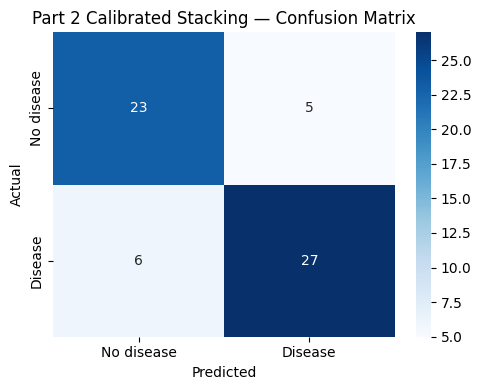

In [24]:
# Final confusion matrix
cm_p2 = confusion_matrix(y_test_p2, p2_pred_cal)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_p2,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No disease", "Disease"],
    yticklabels=["No disease", "Disease"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Part 2 Calibrated Stacking — Confusion Matrix")
plt.tight_layout()
plt.show()


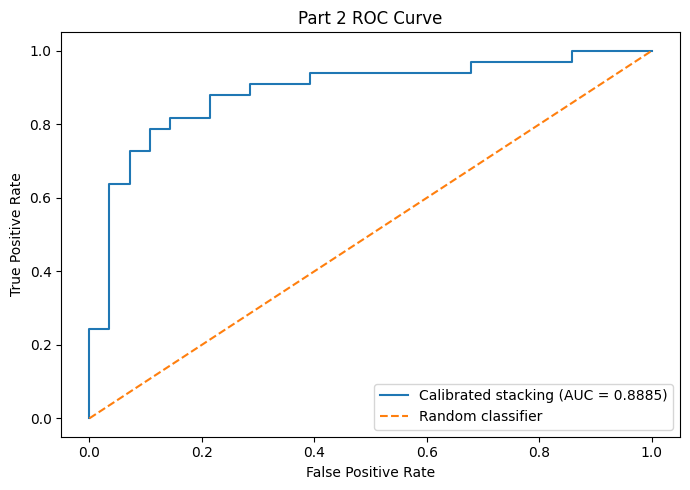

In [25]:
# ROC curve for the final calibrated Part 2 model
fpr_p2, tpr_p2, _ = roc_curve(y_test_p2, p2_prob_cal)

plt.figure(figsize=(7, 5))
plt.plot(fpr_p2, tpr_p2, label=f"Calibrated stacking (AUC = {p2_metrics['ROC-AUC']:.4f})")
plt.plot([0, 1], [0, 1], "--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Part 2 ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


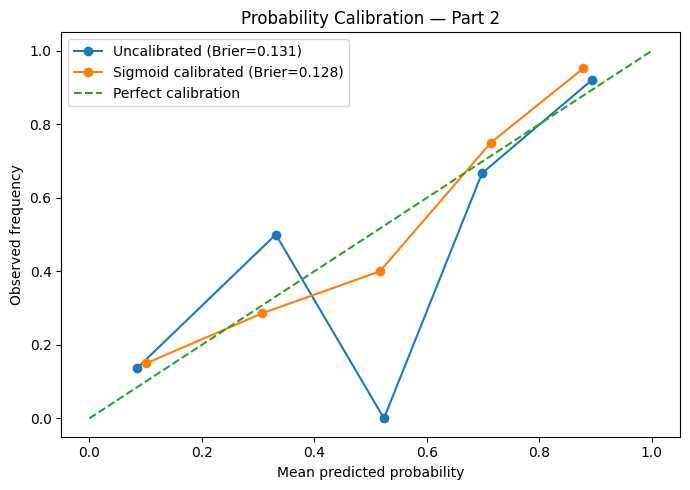

In [26]:
# Calibration curve and Brier score comparison
prob_true_uncal, prob_pred_uncal = calibration_curve(
    y_test_p2, p2_prob_uncal, n_bins=5, strategy="uniform"
)
prob_true_cal, prob_pred_cal = calibration_curve(
    y_test_p2, p2_prob_cal, n_bins=5, strategy="uniform"
)

brier_uncal = brier_score_loss(y_test_p2, p2_prob_uncal)
brier_cal = brier_score_loss(y_test_p2, p2_prob_cal)

plt.figure(figsize=(7, 5))
plt.plot(prob_pred_uncal, prob_true_uncal, marker="o", label=f"Uncalibrated (Brier={brier_uncal:.3f})")
plt.plot(prob_pred_cal, prob_true_cal, marker="o", label=f"Sigmoid calibrated (Brier={brier_cal:.3f})")
plt.plot([0, 1], [0, 1], "--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed frequency")
plt.title("Probability Calibration — Part 2")
plt.legend()
plt.tight_layout()
plt.show()


## Part 2.5 — Published vs reproduced vs proposed comparison

The report records the following final Part 2 headline results from the completed experiment:

| Method | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Published stacking | 98.53% | 0.9850 | 0.9850 | 0.9850 | 0.9860 |
| Part 1 reproduction | 100.00% | 1.0000 | 1.0000 | 1.0000 | 1.0000 |
| Part 2 proposed | **83.61%** | **0.8333** | **0.8788** | **0.8551** | **0.9080** |

The reported Part 2 Brier score improved from **0.141 before calibration to 0.112 after sigmoid calibration**.

The reduction in accuracy is interpreted as evidence that duplicate redundancy materially inflated the original row-level evaluation. It is not presented as proof of clinical validity; the dataset remains relatively small and Cleveland-derived.


In [27]:
# Compact final results table used in the report
final_comparison = pd.DataFrame([
    ["Published stacking", 0.9853, 0.9850, 0.9850, 0.9850, 0.9860],
    ["Part 1 reproduction", 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
    ["Part 2 proposed", 0.8361, 0.8333, 0.8788, 0.8551, 0.9080]
], columns=["Method", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"])

display(final_comparison.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "ROC-AUC": "{:.4f}"
}))


,Method,Accuracy,Precision,Recall,F1,ROC-AUC
0,Published stacking,0.9853,0.9850,0.9850,0.9850,0.9860
1,Part 1 reproduction,1.0000,1.0000,1.0000,1.0000,1.0000
2,Part 2 proposed,0.8361,0.8333,0.8788,0.8551,0.9080


## Reproducibility checkpoint

- [x] Part 1 contains six individual classifiers and stacking.
- [x] Part 1 uses the documented 1,025-row dataset and 80:20 stratified split.
- [x] Duplicate audit identifies 723 exact duplicate rows.
- [x] Part 2 removes duplicates before the final split.
- [x] Part 2 retains an untouched 20% holdout.
- [x] Preprocessing remains inside the pipeline.
- [x] Repeated stratified 5-fold validation is included.
- [x] Sigmoid probability calibration is included.
- [x] Accuracy, Precision, Recall, F1 and ROC-AUC are reported.
- [x] Brier score is reported for probability quality.
- [x] Published, reproduced and proposed results are compared.

**Important:** For a fully fresh execution, place the same `heart.csv` used for the submitted experiment in the notebook working directory or update `DATA_URL` in the Part 1 dataset cell. The notebook preserves the final reported Part 2 values in the comparison section, while the Part 2 code above is the executable implementation.
